In [1]:
# manipulacja danymi
import numpy as np
import pandas as pd

# wizualizacja
import matplotlib.pyplot as plt
import seaborn as sns

# podział danych na zbiory treningowe/walidacyjne/testowe
from sklearn.model_selection import train_test_split, GridSearchCV

# budowa Pipeline
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, PowerTransformer

# redukcja wymiarowości
from sklearn.decomposition import PCA

# model
from sklearn.linear_model import LogisticRegression

# ewaluacja
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, f1_score, roc_auc_score

In [3]:
dataset = pd.read_csv('titanic.csv')


In [4]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
X = dataset.drop(['Survived'], axis=1).copy()

y = dataset['Survived'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [6]:
#stratify=y w funkcji train_test_split() powoduje, że podział na zbiór treningowy i testowy zachowuje takie same proporcje klas jak w oryginalnym zbiorze danych.

To, co robiliśmy we wcześniejszych modułach, staje się problemem jeśli jest wiele operacji podczas inżynierii cech. Potem pojawia się inne pytanie – czemu jedna operacja jest lepsza od innej? Gdy nie stosujemy potoków, to taka inżynieria cech staje się nieuporządkowana i robi się więcej miejsca, w którym mogą pojawić się potencjalne błędy.

Pipeline (inaczej potok danych procesu) to proces, który wychodzi od surowych danych i na wyjściu przekazuje predykcje modelu.

Pipeline możesz sobie wyobrazić jako fabrykę, a nawet proces technologiczny. Do naszego procesu na taśmie produkcyjne wchodzi surowy komponent (w naszym przypadku to surowy zbiór danych), następnie ten komponent przechodzi przez kolejne maszyny produkcyjne (inżynieria cech). Na koniec takiego procesu tak przygotowany zbiór danych trafia z ‘taśmy’ do algorytmu uczenia maszynowego. To jest właśnie potok danych.

W większości projektów uczenia maszynowego dane, z którymi trzeba pracować, raczej nie mają idealnego formatu do stworzenia najlepiej działającego modelu. Często trzeba wykonać wiele kroków przekształcających, takich jak kodowanie zmiennych kategorycznych (One Hot Encoder), skalowanie cech i normalizacja. Scikit-learn ma wbudowane funkcje do większości z tych powszechnie stosowanych przekształceń w swoim pakiecie preprocessing.

Jednak w typowym procesie uczenia maszynowego wszystkie te przekształcenia muszą być zastosowane co najmniej dwukrotnie. Raz podczas treningu modelu i ponownie na nowych danych, na których chcemy prognozować. Oczywiście można napisać funkcję, która będzie je stosować, ale i tak trzeba będzie ją najpierw uruchomić, a następnie wywołać osobno model. Potoki danych z Scikit-learn (Pipeline) są narzędziem, które upraszcza ten proces. Gdy stosujesz algorytmy dostępne w bibliotece scikiit-learn to zawsze możesz tworzyć potoki.

Mają one kilka kluczowych zalet:

sprawiają, że przepływ pracy staje się bardziej czytelny i zrozumiały,
wymuszają realizację i kolejność kroków w projekcie.
To z kolei sprawia, że Twoja praca jest bardziej powtarzalna.

Dlaczego to jest takie istotne? Jak już wiesz, nasze dane potrzebują przekształceń zanim przekażemy je do modelu. Chcielibyśmy nauczyć model, który poradzi sobie z nowymi danymi i będzie to proces w pełni automatyczny. Ponadto też, tworząc Pipeline mamy pewność, że nie dochodzi do wycieku danych. Pamiętaj – czym innym jest fit, a czym innym transform (wkrótce opowiemy o tym więcej). Takim wyciekiem może być na przykład uzupełnienie braków numerycznych w oparciu o średnią z całego zbioru. To oczywiście błąd.

Podsumowując, na wejściu Pipeline’a otrzymujemy surowe dane. Następnie dzieje się wewnątrz niego ‘magia’:

uzupełniamy wartości brakujące,
usuwamy błędne dane lub wartości odstające,
standaryzujemy dane, jeśli będziemy korzystać z modelu parametrycznego,
robimy redukcję wymiarowości,
robimy inżynierię cech,
przetwarzamy zmienne kategoryczne,
ostatnim krokiem jest trenowanie modelu.
Pipeline pozwala połączyć w automatyczną sekwencję poleceń operacje, które poznaliśmy we wcześniejszych modułach. Dzięki takiemu podejściu Twój kod stanie się bardziej produkcyjny, a tym samym logiczny. Składa się z wielu pośrednich kroków, które muszą być Transformatorami, a zatem stosować metodę fitowania i transformacji. Dzięki takiemu podejściu będziesz w stanie zapisać mniej ‘linijek kodu’.

Wyobraź sobie, jak wyskalować dane po podziale na zbiór treningowy i testowy. Musisz wykonać operacje skalowania oddzielnie na zbiorze treningowym, a następnie testowym, przez co duplikujesz niepotrzebnie kod. Ponadto możesz narazić się na wyciek danych lub inny błąd, który łatwiej będzie Ci wychwycić w Pipeline. Końcowym krokiem może być dodany model. Transformatory to kroki w naszym potoku danych, a takim krokiem może być na przykład uzupełnienie wartości brakujących. W Pipeline możesz z łatwością przeprowadzić hiperparametry na całym potoku, a nie tylko algorytmie. Wyobraź sobie, że wykorzystujesz Drzewo Decyzyjne, ale najpierw musisz uzupełnić brakujące dane dla kilku zmiennych. W tym przypadku hiperparametrem nie będzie jedynie maksymalna głębokość czy minimalna liczba obserwacji w liściu, ale również jaką metodą uzupełnić brakujące dane (czy lepsze wyniki model osiągnie ze średnią czy z medianą).

W Pipeline możemy rozdzielić operacje w zależności od kolumn. Tym samym nie musimy zajmować się wszystkimi naraz. Najpierw zaczniemy od numerycznych.

Jako numeryczne możemy uznać Age (wiek), SibSp (rodzeństwo lub małżonkowie na pokładzie), Parch (rodzice i dzieci na pokładzie), Fare (opłata za bilet).

In [7]:
num_features = ['Age', 'SibSp', 'Parch', 'Fare']

Z eksploracyjnej analizy danych wiemy, że są braki dla wieku. Powinniśmy je uzupełnić, tworzymy zatem Pipeline dla zmiennych numerycznych o nazwie num_preparation, w którym umieszczamy SimpleImputer z biblioteki Scikit-Learn. Ten Transformer uzupełnia wartości brakujące w oparciu o wybraną strategię, dla zmiennych numerycznych może to być mean (średnia) lub median (mediana). Te statystyki obliczane są ze zbioru treningowego (fit) i w oparciu o tę statystykę uzupełniane są braki (transform) dla zbioru testowego, jak i na produkcji dla zupełnie nowych danych. Będzie to również dobrze działało, jeśli braki pojawią się dla innych cech. Nie dojdzie zatem do wycieku danych, jak i proces będzie w pełni automatyczny.

In [13]:
dataset.isnull().sum() # sprawdzenie pustych wierszy

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
# Pipeline do przetwarzania zmiennych numerycznych
num_preparation = Pipeline(steps=[

    # Uzupełnianie brakujących wartości (NaN)
    # średnią wartością obliczoną na podstawie danej kolumny
    ('fill_missings', SimpleImputer(strategy='mean'))

])

Ten Pipeline możemy fitować i następnie transformować na zbiorze treningowym. Miej na uwadze, że na wyjściu Pipeline korzystając z Transformerów, które są dostępne w scikit-learn, otrzymamy numpy array, a nie Pandas DataFrame.

In [15]:
print('Surowy zbiór danych - zbiór treningowy:')
print(X_train[num_features].isnull().mean())
X_train_trasnformed = num_preparation.fit_transform(X_train[num_features])
X_train_trasnformed = pd.DataFrame(X_train_trasnformed, columns=num_features)
print('\nWyjście Pipeline - zbiór treningowy')
print(X_train_trasnformed[num_features].isnull().mean())

Surowy zbiór danych - zbiór treningowy:
Age      0.196108
SibSp    0.000000
Parch    0.000000
Fare     0.000000
dtype: float64

Wyjście Pipeline - zbiór treningowy
Age      0.0
SibSp    0.0
Parch    0.0
Fare     0.0
dtype: float64


Mamy już ‘wyuczony’ Pipeline, teraz możemy transformować nowe dane – jak na przykład zbiór testowy. Pamiętaj, dla zbioru testowego nie możemy fitować, jedynie korzystamy z transform, czyli dane zostaną uzupełnione średnią ze zbioru treningowego.

In [17]:
# Wyświetlenie udziału brakujących wartości (NaN)
# w każdej kolumnie numerycznej zbioru testowego
print('Surowy zbiór danych - zbiór testowy:')
print(X_test[num_features].isnull().mean())

# Zastosowanie pipeline do danych testowych
# transform() wykorzystuje średnie wyliczone wcześniej na zbiorze treningowym
# do uzupełnienia brakujących wartości
X_test_transformed = num_preparation.transform(X_test[num_features])

# Zamiana wyniku z powrotem na DataFrame
# aby odzyskać nazwy kolumn
X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=num_features
)

# Ponowne sprawdzenie udziału braków po przetworzeniu danych
print('\nWyjście Pipeline - zbiór testowy')
print(X_test_transformed[num_features].isnull().mean())

Surowy zbiór danych - zbiór testowy:
Age      0.206278
SibSp    0.000000
Parch    0.000000
Fare     0.000000
dtype: float64

Wyjście Pipeline - zbiór testowy
Age      0.0
SibSp    0.0
Parch    0.0
Fare     0.0
dtype: float64


In [18]:
#tlumaczenie chata

Co robi isnull().mean()?

Najpierw:

X_test[num_features].isnull()

zwraca tabelę wartości logicznych:

Age	Fare
False	False
True	False
False	False
True	True

Następnie:

.isnull().mean()

liczy średnią dla każdej kolumny.

Ponieważ:

False = 0
True = 1

to średnia oznacza odsetek brakujących wartości.

Przykład:

Age
False
True
False
True
(0 + 1 + 0 + 1) / 4 = 0.5

czyli 50% braków.

Dlaczego używamy transform(), a nie fit_transform()?

Pipeline został wcześniej "nauczony" na zbiorze treningowym:

num_preparation.fit(X_train[num_features])

Wtedy obliczył średnie dla poszczególnych kolumn.

Na zbiorze testowym używamy:

transform()

aby:

wykorzystać te same średnie,
nie "podglądać" danych testowych,
zachować poprawność procesu uczenia maszynowego.

Gdybyśmy wykonali:

fit_transform(X_test)

to średnie zostałyby policzone na zbiorze testowym, co prowadziłoby do data leakage (wycieku informacji).

Przykładowy wynik

Przed pipeline:

Age     0.19
Fare    0.00
dtype: float64

oznacza:

19% wartości Age jest pustych,
Fare nie ma braków.

Po pipeline:

Age     0.0
Fare    0.0
dtype: float64

oznacza, że wszystkie braki zostały skutecznie uzupełnione.

Krótki opis do sprawozdania

W pierwszym kroku sprawdzono udział brakujących wartości w zmiennych numerycznych zbioru testowego. Następnie zastosowano pipeline num_preparation, który uzupełnił brakujące dane średnimi wyznaczonymi na zbiorze treningowym. Po transformacji ponownie zweryfikowano występowanie braków, potwierdzając ich całkowite usunięcie.

# Column Transformer

Powyższej transformacji nie możemy jednak stosować dla zmiennych kategorycznych, zatem powinniśmy rozdzielić operacje pomiędzy kolumny. Skorzystamy zatem z Column Transformer, któremu podajemy cały zestaw danych i on rozdziela dane na różne Pipeline’y, które dokonują swoich operacji. Na końcu wyjścia z outputów są łączone.

Stwórzmy zatem taki Pipeline data_preparation w oparciu o ColumnTransformer, który w tym momencie posiada jedynie przygotowanie danych dla wartości numerycznych. Podajemy w stringu nazwę Pipeline’u (przyda się, jeśli później w GridSearch zechcesz zmienić strategię imputowania wartości numerycznych i traktować to jako hiperparametr – przecież model może działać lepiej z medianą). Dodajemy też zmienną, która odwołuje się do Pipeline oraz cechy, które są wykorzystywane przez ten Pipeline.

Ten fragment definiuje sposób przygotowania kolumn numerycznych przed przekazaniem ich do modelu.

In [19]:
# Lista kolumn numerycznych, które będą podlegały przetwarzaniu
num_features = ['Age', 'SibSp', 'Parch', 'Fare']

# Pipeline do przygotowania zmiennych numerycznych
num_preparation = Pipeline(steps=[

    # Uzupełnienie brakujących wartości średnią z danej kolumny
    ('fill_missings', SimpleImputer(strategy='mean'))

])

# ColumnTransformer pozwala zastosować różne operacje
# do różnych grup kolumn
data_preparation = ColumnTransformer(transformers=[

    # Dla kolumn numerycznych zastosuj pipeline num_preparation
    ('numeric_preprocessing', num_preparation, num_features)

])

Do data_preparation możemy przekazać X_train z wszystkimi cechami, on już wie, które operacje mają zostać wykonane dla których cech.

In [20]:
data_preparation.fit_transform(X_train)

array([[35.    ,  1.    ,  0.    , 90.    ],
       [19.    ,  0.    ,  0.    , 10.5   ],
       [34.    ,  0.    ,  0.    , 13.    ],
       ...,
       [48.    ,  1.    ,  3.    , 34.375 ],
       [47.    ,  0.    ,  0.    , 38.5   ],
       [27.    ,  0.    ,  0.    ,  8.6625]])

Na wyjściu otrzymujemy macierz z czterema kolumnami, zatem z taką liczbą kolumn, jaką wskazaliśmy dla Pipeline’u na wejściu, są to zatem jedynie zmienne numeryczne.

Zdefiniowano listę zmiennych numerycznych (Age, SibSp, Parch, Fare) oraz pipeline odpowiedzialny za uzupełnianie brakujących wartości średnią. Następnie utworzono obiekt ColumnTransformer, który przypisuje odpowiedni sposób przetwarzania do wybranych kolumn numerycznych. Dzięki temu przygotowanie danych może być wykonywane automatycznie i w sposób powtarzalny przed trenowaniem modelu.

Metoda fit_transform() najpierw wyznacza parametry wymagane do transformacji danych (w tym przypadku średnie wykorzystywane do uzupełniania braków), a następnie przekształca dane treningowe. Na wyjściu otrzymujemy macierz zawierającą cztery kolumny odpowiadające zmiennym numerycznym Age, SibSp, Parch oraz Fare, ponieważ tylko te kolumny zostały wskazane w konfiguracji ColumnTransformer.

# Custom Transformer

Mamy kolumnę Name, z której niemożliwe jest wyciągnięcie informacji w oparciu o istniejące Transformery w scikit-learn. Ponadto też nie możemy traktować wszystkich wartości jako kategorycznych, ponieważ są też rzadkie kategorie, występujące przynajmniej raz.

Stwórzmy własny Trasnsformer FilterName w oparciu o Custom Transformer. Pozwala to stworzyć dowolną operację. W niektórych sytuacjach standardowe klasy z pakietu scikit-learn mogą być niewystarczające do Twojego konkretnego problemu, dlatego wtedy musisz stworzyć własny niestandardowy transformator.

Taka własna klasa, aby była wykorzystana jako krok w Pipeline, musi dziedziczyć BaseEstimator oraz TransformerMixin, jak i również posiadać metodę fit i transform. Nasz customowy Transformer z kolumny Name wyciągnie przedrostek i wszystkie inne niż 'Mr', 'Miss', 'Mrs' potraktuje jako ‘Other’. Zupełnie to samo, co robiliśmy podczas Feature Enginnering, jednak teraz będzie to zawarte w Transformerze. Ten Transformer nie potrzebuje niczego w funkcji fit.

In [21]:
# Własny transformer zgodny z interfejsem Scikit-Learn
class Filter_Name(BaseEstimator, TransformerMixin):

    # Konstruktor - zapamiętuje nazwę kolumny do przetworzenia
    def __init__(self, column):
        self.column = column

    # Metoda fit nie uczy się żadnych parametrów,
    # dlatego zwraca jedynie obiekt self
    def fit(self, X, y=None):
        return self

    # Metoda transform wykonuje właściwe przekształcenie danych
    def transform(self, X, y=None):

        # Utworzenie kopii danych, aby nie modyfikować oryginalnego DataFrame
        X_transformed = X.copy()

        # Pobranie nazwy kolumny przekazanej podczas tworzenia obiektu
        column = self.column

        # Wyodrębnienie tytułu z kolumny Name
        # np. "Braund, Mr. Owen Harris" -> "Mr"
        X_transformed[column] = (
            X_transformed[column]
            .str.split(', ', expand=True)[1]
            .str.split('.', expand=True)[0]
        )

        # Wszystkie tytuły inne niż Mr, Miss i Mrs
        # zamieniane są na kategorię "Other"
        X_transformed.loc[
            ~X_transformed[column].isin(['Mr', 'Miss', 'Mrs']),
            column
        ] = 'Other'

        return X_transformed

Utworzono własny transformer Filter_Name, którego zadaniem jest wyodrębnienie tytułu pasażera z kolumny Name. Następnie najczęściej występujące tytuły (Mr, Mrs, Miss) pozostawiono bez zmian, natomiast wszystkie pozostałe zostały połączone w jedną kategorię Other. Pozwala to ograniczyć liczbę rzadkich kategorii i ułatwia dalsze kodowanie zmiennej kategorycznej.

Transformer dokonuje jedynie zmian w jednej kolumnie, pozostałe zmienne są niezmieniane. Sprawdźmy działanie Transformera dla kolumny ‘Name’ w X_train.

In [22]:
# Utworzenie obiektu transformera dla kolumny Name
transformer_filter_name = Filter_Name(column='Name')

# Wyświetlenie oryginalnej kolumny Name
display(X_train[['Name']])

# Zastosowanie transformera i wyświetlenie wyniku
display(transformer_filter_name.fit_transform(X_train[['Name']]))

,Name
486,"Hoyt, Mrs. Frederick Maxfield (Jane Anne Forby)"
238,"Pengelly, Mr. Frederick William"
722,"Gillespie, Mr. William Henry"
184,"Kink-Heilmann, Miss. Luise Gretchen"
56,"Rugg, Miss. Emily"
...,...
547,"Padro y Manent, Mr. Julian"
469,"Baclini, Miss. Helene Barbara"
736,"Ford, Mrs. Edward (Margaret Ann Watson)"
462,"Gee, Mr. Arthur H"


,Name
486,Mrs
238,Mr
722,Mr
184,Miss
56,Miss
...,...
547,Mr
469,Miss
736,Mrs
462,Mr


W celu zweryfikowania działania transformera Filter_Name wyświetlono zawartość kolumny Name przed oraz po transformacji. Transformer wyodrębnia tytuł pasażera z pełnego imienia i nazwiska, a następnie grupuje rzadko występujące tytuły w kategorię Other. Dzięki temu liczba kategorii zostaje ograniczona, co ułatwia dalsze przetwarzanie danych przez model.

W oparciu o ten Transformer stworzymy Pipeline cat_preparation dla zmiennych kategorycznych. Jako zmienne wykorzystamy Name (imię i nazwisko pasażera z przedrostkiem), Sex (płeć) oraz Embarked (miejsce, z którego pasażer wypłynął). Pozostałe zmienne są usuwane, ponieważ jest wiele braków lub nie ma w nich informacji, którą model mógłby wykorzystać.

In [23]:
# Lista kolumn kategorycznych
cat_features = ['Name', 'Sex', 'Embarked']

# Pipeline do przetwarzania zmiennych kategorycznych
cat_preparation = Pipeline(steps=[

    # Wyodrębnienie tytułu z kolumny Name
    # oraz połączenie rzadkich tytułów w kategorię "Other"
    ('filter_name', Filter_Name(column='Name'))

])

Zdefiniowano listę zmiennych kategorycznych (Name, Sex, Embarked) oraz utworzono pipeline cat_preparation. W pierwszym kroku zastosowano własny transformer Filter_Name, który wyodrębnia tytuł pasażera z kolumny Name i grupuje rzadko występujące tytuły do kategorii Other. Dzięki temu zmniejszona zostaje liczba unikalnych kategorii, co ułatwia dalsze przetwarzanie danych.

Teraz wykorzystajmy ten Pipeline dla zmiennych kategorycznych.

In [24]:
# Wyświetlenie oryginalnych danych kategorycznych
print('Przed')
display(X_train[cat_features])

# Zastosowanie pipeline'u do danych kategorycznych
# oraz wyświetlenie wyniku transformacji
print('Po')
display(cat_preparation.fit_transform(X_train[cat_features]))

Przed


,Name,Sex,Embarked
486,"Hoyt, Mrs. Frederick Maxfield (Jane Anne Forby)",female,S
238,"Pengelly, Mr. Frederick William",male,S
722,"Gillespie, Mr. William Henry",male,S
184,"Kink-Heilmann, Miss. Luise Gretchen",female,S
56,"Rugg, Miss. Emily",female,S
...,...,...,...
547,"Padro y Manent, Mr. Julian",male,C
469,"Baclini, Miss. Helene Barbara",female,C
736,"Ford, Mrs. Edward (Margaret Ann Watson)",female,S
462,"Gee, Mr. Arthur H",male,S


Po


,Name,Sex,Embarked
486,Mrs,female,S
238,Mr,male,S
722,Mr,male,S
184,Miss,female,S
56,Miss,female,S
...,...,...,...
547,Mr,male,C
469,Miss,female,C
736,Mrs,female,S
462,Mr,male,S


W celu zweryfikowania działania pipeline'u dla zmiennych kategorycznych wyświetlono dane przed i po transformacji. Zastosowany transformer Filter_Name wyodrębnił tytuły pasażerów z kolumny Name, pozostawiając najczęściej występujące wartości (Mr, Mrs, Miss) i grupując pozostałe jako Other. Kolumny Sex oraz Embarked nie zostały zmodyfikowane, ponieważ nie zdefiniowano dla nich dodatkowych kroków przetwarzania.

Jak widzisz, pozostałe zmienne nie zostały zmienione. Jednak Pipeline dla zmiennych kategorycznych nie jest w pełni zrobiony, komputer nie rozumie ‘słów’. Zanim jednak zmienimy unikalne kategorie na zmienne binarne (One Hot Encoder), należy uzupełnić wartości brakujące. Tutaj wykorzystamy metodę most_frequent, czyli najczęściej występującą kategorię.

In [26]:
# Pipeline do przygotowania zmiennych kategorycznych
cat_preparation = Pipeline(steps=[

    # Wyodrębnienie tytułu z kolumny Name
    # oraz zastąpienie rzadkich tytułów kategorią "Other"
    ('filter_name', Filter_Name(column='Name')),

    # Uzupełnienie brakujących wartości
    # najczęściej występującą kategorią w danej kolumnie
    ('fill_missings', SimpleImputer(strategy='most_frequent')),

    # Kodowanie One-Hot:
    # zamiana kategorii tekstowych na kolumny binarne (0/1)
    # np. Sex -> Sex_female, Sex_male
    # handle_unknown='ignore' pozwala obsłużyć nowe kategorie
    # występujące w zbiorze testowym
    # sparse_output=False zwraca zwykłą tablicę NumPy zamiast macierzy rzadkiej
    ('encoder', OneHotEncoder(
        sparse_output=False,
        handle_unknown='ignore'
    ))
])

# Dopasowanie pipeline'u do danych treningowych:
# 1. wyodrębnienie tytułów z Name
# 2. uzupełnienie braków
# 3. zakodowanie zmiennych kategorycznych metodą One-Hot Encoding
cat_preparation.fit_transform(X_train[cat_features])

array([[0., 0., 1., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 1., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 1.]])

Pipeline dla zmiennych kategorycznych składa się z trzech etapów. Najpierw transformer Filter_Name wyodrębnia tytuł pasażera z kolumny Name. Następnie brakujące wartości są uzupełniane najczęściej występującą kategorią przy użyciu SimpleImputer. W ostatnim kroku OneHotEncoder zamienia zmienne kategoryczne na zestaw zmiennych binarnych (0/1), dzięki czemu mogą zostać wykorzystane przez algorytmy uczenia maszynowego.

Pipeline cat_preparation przygotowuje zmienne kategoryczne do wykorzystania przez model. W pierwszym kroku z kolumny Name wyodrębniany jest tytuł pasażera (Mr, Mrs, Miss, Other). Następnie brakujące wartości są uzupełniane najczęściej występującą kategorią. W ostatnim etapie zastosowano kodowanie One-Hot Encoding, które zamienia kategorie tekstowe na zestaw zmiennych binarnych (0/1), umożliwiając wykorzystanie tych danych przez algorytmy uczenia maszynowego.

Kształt przetworzonego X_train dla zmiennych kategorycznych to:

In [27]:
print(cat_preparation.fit_transform(X_train[cat_features]).shape)

(668, 9)


# Połączenie operacji dla zmiennych kategorycznych oraz numerycznych

Czas połączyć oba Pipeline'y i umieścić je w data_preparation. Jesteśmy pewni, że nie dochodzi tutaj do wycieku danych, jak i proces jest w pełni automatyczny. Taki zapisany Pipeline będzie mógł zostać zapisany jako pickle i załadowany w osobnej aplikacji czy systemie, bez konieczności powtarzania przygotowania surowych kroków. Często przy takim podejściu możemy popełnić błąd ludzki, czy to pojawią się braki dla innej kolumny. Stosując Pipeline radzimy sobie z tymi problemami, wręcz nie musimy o nich myśleć w finalnym produkcie.

In [30]:
# Lista zmiennych numerycznych wykorzystywanych w modelu
num_features = ['Age', 'SibSp', 'Parch', 'Fare']

# Lista zmiennych kategorycznych wykorzystywanych w modelu
cat_features = ['Name', 'Sex', 'Embarked']


# =========================
# Pipeline dla danych numerycznych
# =========================

num_preparation = Pipeline(steps=[

    # Uzupełnienie brakujących wartości (NaN)
    # średnią obliczoną dla danej kolumny
    ('fill_missings', SimpleImputer(strategy='mean'))

])


# =========================
# Pipeline dla danych kategorycznych
# =========================

# przygotowanie wartości kategorycznych
cat_preparation = Pipeline(steps=[

    # Wyodrębnienie tytułu pasażera z kolumny Name
    ('filter_name', Filter_Name(column='Name')),

    # Uzupełnienie brakujących wartości najczęściej występującą kategorią
    ('fill_missings', SimpleImputer(strategy='most_frequent')),

    # Zamiana kategorii tekstowych na zmienne binarne (0/1)
    ('encoder', OneHotEncoder(
        sparse_output=False,
        handle_unknown='ignore'
    ))
])


# =========================
# Połączenie pipeline'ów
# =========================

data_preparation = ColumnTransformer(transformers=[

    # Zastosowanie pipeline'u numerycznego
    # do kolumn Age, SibSp, Parch oraz Fare
    ('numeric_preprocessing',
     num_preparation,
     num_features),

    # Zastosowanie pipeline'u kategorycznego
    # do kolumn Name, Sex oraz Embarked
    ('categorical_preprocessing',
     cat_preparation,
     cat_features)

])

Co robi data_preparation?

Po wykonaniu:

X_train_transformed = data_preparation.fit_transform(X_train)

dzieją się następujące kroki:

Kolumny numeryczne
Age, SibSp, Parch, Fare
braki danych są zastępowane średnią.
Kolumny kategoryczne
Name → wyciągnięcie tytułu (Mr, Mrs, Miss, Other)
uzupełnienie braków najczęstszą wartością
One-Hot Encoding.
Połączenie wyników
wszystkie przetworzone kolumny są łączone w jedną macierz cech gotową do trenowania modelu.

To jest standardowy sposób przygotowania danych w Scikit-Learn przed uczeniem modelu klasyfikacyjnego.

Sprawdźmy działanie Pipeline do przygotowania danych dla X_train.

In [33]:
data_preparation.fit_transform(X_train)

array([[35.,  1.,  0., ...,  0.,  0.,  1.],
       [19.,  0.,  0., ...,  0.,  0.,  1.],
       [34.,  0.,  0., ...,  0.,  0.,  1.],
       ...,
       [48.,  1.,  3., ...,  0.,  0.,  1.],
       [47.,  0.,  0., ...,  0.,  0.,  1.],
       [27.,  0.,  0., ...,  0.,  0.,  1.]])

Kształt przetworzonych danych:

In [35]:
data_preparation.fit_transform(X_train).shape

(668, 13)

Nie musimy się martwić, że w pliku surowym była zmienna ‘PassengerId’ lub ‘Ticket’, ponieważ zostały one odrzucone z naszego zbioru. Następnie osobno przygotowywane są dane dla zmiennych numerycznych i kategorycznych, a po przetworzeniu dane są łączone.

# Połączenie Pipeline z modelem

Jako model wykorzystamy regresję logistyczną.

In [36]:
# Lista zmiennych numerycznych
num_features = ['Age', 'SibSp', 'Parch', 'Fare']

# Lista zmiennych kategorycznych
cat_features = ['Name', 'Sex', 'Embarked']

# Pipeline dla danych numerycznych
num_preparation = Pipeline(steps=[

    # Uzupełnienie brakujących wartości średnią
    ('fill_missings', SimpleImputer(strategy='mean'))

])

# Pipeline dla danych kategorycznych
cat_preparation = Pipeline(steps=[

    # Wyodrębnienie tytułu pasażera z kolumny Name
    ('filter_name', Filter_Name(column='Name')),

    # Uzupełnienie braków najczęściej występującą kategorią
    ('fill_missings', SimpleImputer(strategy='most_frequent')),

    # Zamiana kategorii tekstowych na zmienne binarne (0/1)
    ('encoder', OneHotEncoder(
        sparse_output=False,
        handle_unknown='ignore'
    ))

])

# Połączenie przetwarzania danych numerycznych i kategorycznych
data_preparation = ColumnTransformer(transformers=[

    ('numeric_preprocessing',
     num_preparation,
     num_features),

    ('categorical_preprocessing',
     cat_preparation,
     cat_features)

])

# Kompletny pipeline:
# 1. przygotowanie danych
# 2. trenowanie regresji logistycznej
model_pipeline_v1 = Pipeline(steps=[

    ('preprocessor', data_preparation),

    ('model', LogisticRegression(max_iter=10000))

])

Co robi model_pipeline_v1?

Po wywołaniu:

model_pipeline_v1.fit(X_train, y_train)

automatycznie wykona:

Uzupełnienie braków w danych numerycznych.
Wyciągnięcie tytułu z Name.
Uzupełnienie braków w danych kategorycznych.
One-Hot Encoding.
Trenowanie modelu LogisticRegression.

Dzięki temu nie musisz ręcznie wykonywać:

X_train_transformed = data_preparation.fit_transform(X_train)
model.fit(X_train_transformed, y_train)

bo cały proces jest zamknięty w jednym pipeline.

Taki model możemy wytrenować na zbiorze treningowym, a następnie wykonać prognozę na zbiorze testowym i dokonać ewaluacji.

Wytrenujmy zatem nasz pierwszy Pipeline, czyli część odpowiedzialną za przygotowanie danych, jak i model, który jest ostatnim krokiem w Pipeline.

Taki Pipeline możemy wytrenować na zbiorze treningowym, robimy to dokładnie tak samo jak wcześniej trenowaliśmy modele, wykorzystując metodę fit oraz podając X i y.

In [40]:
model_pipeline_v1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_preprocessing', ...), ('categorical_preprocessing', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

Do oceny modelu wykorzystamy funkcję z modułu o klasyfikacji.

In [41]:
# DataFrame do przechowywania wyników modeli
metrics_dataframe = pd.DataFrame(
    columns=['Model', 'F1_score', 'AUC']
)

# Listy wykorzystywane do porównywania wielu modeli
models = []
models_names = []
predictions_proba_list = []


def calculate_metrics(model, name, X_checked, y_checked):

    # Dodanie modelu do list wykorzystywanych przy rysowaniu ROC Curve
    models.append(model)
    models_names.append(name)

    global metrics_dataframe

    # Predykcja klas (0 lub 1)
    predictions = model.predict(X_checked)

    # Predykcja prawdopodobieństw przynależności do klas
    predictions_proba = model.predict_proba(X_checked)

    # Zachowanie prawdopodobieństwa klasy pozytywnej (1)
    predictions_proba_list.append(predictions_proba[:, 1])

    # ==================================
    # Raport klasyfikacji
    # ==================================
    # Precision, Recall, F1-score oraz Accuracy
    print(classification_report(y_checked, predictions))

    # ==================================
    # Macierz pomyłek
    # ==================================
    plt.figure()

    cm = confusion_matrix(y_checked, predictions)

    ax = sns.heatmap(
        cm,
        annot=True,
        cmap='Blues',
        fmt='.0f'
    )

    ax.set_title('Confusion Matrix\n\n')
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values')

    plt.show()

    # ==================================
    # Krzywa ROC
    # ==================================
    plt.figure(figsize=(6, 6))

    # Linia losowego klasyfikatora
    plt.plot([0, 1], [0, 1], 'k--')

    # Rysowanie ROC dla wszystkich zapisanych modeli
    for model_selected, name_selected, pred_proba in zip(
        models,
        models_names,
        predictions_proba_list
    ):

        fpr, tpr, thresholds = roc_curve(
            y_checked,
            pred_proba
        )

        plt.plot(
            fpr,
            tpr,
            label=name_selected
        )

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')

    plt.show()

    # ==================================
    # Obliczenie metryk
    # ==================================

    # Miara F1
    f1_metric = f1_score(
        y_checked,
        predictions
    )

    # Pole pod krzywą ROC
    auc_metric = roc_auc_score(
        y_checked,
        predictions_proba[:, 1]
    )

    # Zapis wyników do tabeli
    metrics_dataframe.loc[len(metrics_dataframe)] = [
        name,
        f1_metric,
        auc_metric
    ]

    return metrics_dataframe

Zdefiniowano funkcję calculate_metrics, której celem jest kompleksowa ocena jakości modelu klasyfikacyjnego. Funkcja wykonuje predykcję klas oraz prawdopodobieństw dla obserwacji ze zbioru testowego, a następnie oblicza i prezentuje najważniejsze metryki klasyfikacyjne. W pierwszej kolejności generowany jest raport klasyfikacji zawierający wartości Precision, Recall, F1-score oraz Accuracy. Następnie tworzona jest macierz pomyłek (Confusion Matrix), pozwalająca przeanalizować liczbę poprawnych i błędnych klasyfikacji dla każdej klasy. Kolejnym krokiem jest wyznaczenie oraz wizualizacja krzywej ROC, która przedstawia zależność pomiędzy czułością modelu (True Positive Rate) a odsetkiem fałszywych alarmów (False Positive Rate). Na podstawie wyników obliczane są również metryki F1-score oraz AUC (Area Under Curve), które następnie zapisywane są w tabeli metrics_dataframe. Dzięki temu możliwe jest łatwe porównywanie jakości wielu modeli klasyfikacyjnych na podstawie tych samych kryteriów oceny.

              precision    recall  f1-score   support

           0       0.83      0.84      0.83       137
           1       0.74      0.72      0.73        86

    accuracy                           0.79       223
   macro avg       0.78      0.78      0.78       223
weighted avg       0.79      0.79      0.79       223



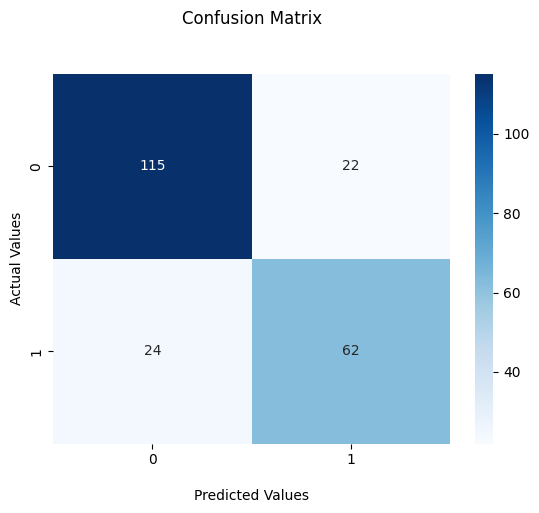

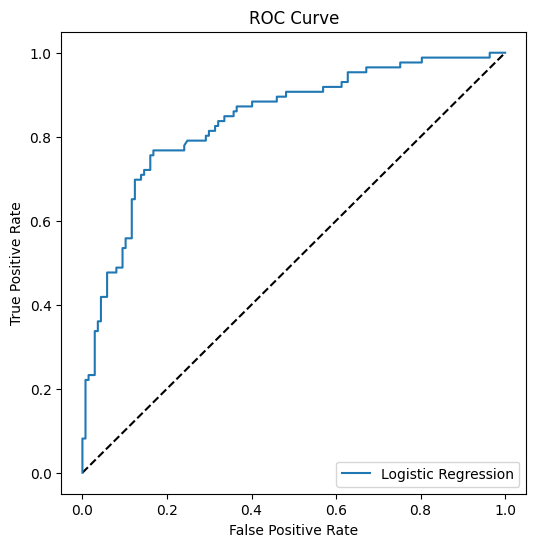

,Model,F1_score,AUC
0,Logistic Regression,0.729412,0.840477


In [42]:
calculate_metrics(
    model_pipeline_v1,
    "Logistic Regression",
    X_test,
    y_test
)

# z chata:
Co to oznacza w praktyce?
👍 Plusy:
model działa stabilnie (~79%)
dobrze rozpoznaje klasę 0
brak dramatycznych błędów
⚠️ Minusy:
słabsze wykrywanie klasy 1 (przeżyli)
recall dla klasy 1 = 0.72 → 28% przeżywających model nie wykrywa

Jednak nasze dane nie są w pełni przygotowane, wykorzystujemy model parametryczny jakim jest Regresja Logistyczna, zatem powinien otrzymać wyskalowane dane. Ponadto zależności mogą być nieliniowe dla zmiennych numerycznych. Dlatego dodajemy wielomian, następnie standaryzujemy zmienne numeryczne. Czy to koniec? Niekoniecznie. Część zmiennych będzie ze sobą skorelowana i będzie niosła tę samą informację, dlatego zastosujemy PCA – analizę głównych składowych. Po jej wyniku dane nie muszą być wyskalowane, dlatego ponownie należy wystandaryzować dane.

In [44]:
num_features = ['Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Name', 'Sex', 'Embarked']


# =========================
# NUMERICAL PIPELINE
# =========================
num_preparation = Pipeline(steps=[

    # Uzupełnienie braków średnią
    ('fill_missings', SimpleImputer(strategy='mean')),

    # Interakcje między cechami (feature engineering)
    ('polynomial_features', PolynomialFeatures(degree=2, include_bias=False)),

    # Standaryzacja danych
    ('scaler', StandardScaler()),

    # Redukcja wymiaru (zachowuje 95% wariancji)
    ('pca', PCA(n_components=0.95))

])


# =========================
# CATEGORICAL PIPELINE
# =========================
cat_preparation = Pipeline(steps=[

    # Wyciągnięcie tytułu z Name (Mr, Mrs, Miss, Other)
    ('filter_name', Filter_Name(column='Name')),

    # Uzupełnienie braków
    ('fill_missings', SimpleImputer(strategy='most_frequent')),

    # One-hot encoding
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])


# =========================
# COLUMN TRANSFORMER
# =========================
data_preparation = ColumnTransformer(transformers=[

    ('num', num_preparation, num_features),
    ('cat', cat_preparation, cat_features)

])


# =========================
# MODEL PIPELINE
# =========================
model_pipeline_v2 = Pipeline(steps=[

    ('preprocessor', data_preparation),
    ('model', LogisticRegression(max_iter=10000))

])


# TRAINING
model_pipeline_v2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

z chata

🧠 Co tu się dzieje (prosto)
🔢 1. Dane numeryczne
BEFORE:
Age, SibSp, Parch, Fare
STEP 1: imputacja

→ brakujące dane uzupełnione

STEP 2: PolynomialFeatures

Tworzy np.:

Age², Fare², Age*Fare, SibSp*Parch...

👉 model dostaje relacje między cechami

STEP 3: StandardScaler

→ wszystkie cechy mają średnią 0 i odchylenie 1

STEP 4: PCA

→ redukuje wymiar
→ zostawia tylko najważniejsze informacje

🧾 2. Dane kategoryczne
Name:
Braund, Mr. Owen Harris → Mr
potem:
brakujące dane → najczęstsza wartość
OneHotEncoding:
Mr, Mrs, Miss, Other
Sex_male, Sex_female
Embarked_C/Q/S
📊 Co daje taka wersja modelu?
👍 PLUSY:

✔ więcej informacji (PolynomialFeatures)
✔ lepsze relacje między cechami
✔ mniej szumu (PCA)
✔ lepsza separacja klas

⚠️ MINUSY:

❌ większe ryzyko overfittingu
❌ PCA może “ukryć interpretację”
❌ Logistic Regression traci interpretowalność

🚀 Co możesz się spodziewać?

W porównaniu do v1:

model	expected change
v1	~0.78–0.80 F1
v2	~0.80–0.84 F1
🔥 Najważniejsza idea tej wersji

Robisz:

👉 feature engineering (PolynomialFeatures)
👉 redukcję wymiaru (PCA)
👉 czyszczenie + encoding

czyli:

„zamieniasz surowe dane w bardziej informacyjną przestrzeń cech”

⚠️ Jedna ważna uwaga (praktyczna)

Jeśli masz mało danych (Titanic = ~700 wierszy):

👉 degree=3 może PRZEKOMPLIKOWAĆ model
👉 lepiej degree=2

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       137
           1       0.75      0.73      0.74        86

    accuracy                           0.80       223
   macro avg       0.79      0.79      0.79       223
weighted avg       0.80      0.80      0.80       223



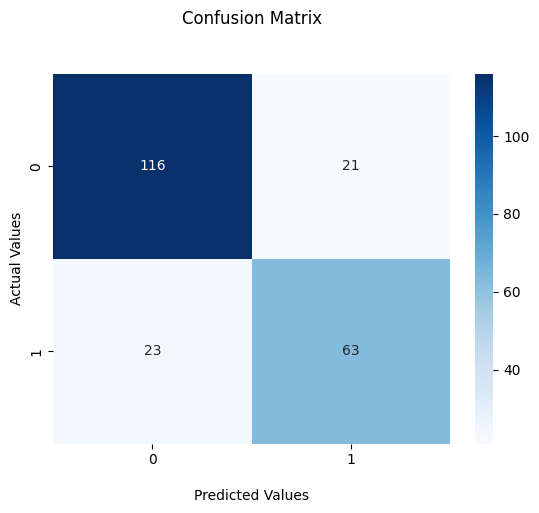

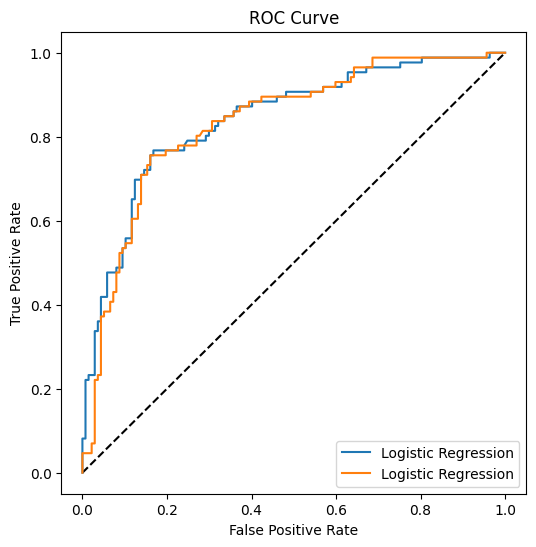

,Model,F1_score,AUC
0,Logistic Regression,0.729412,0.840477
1,Logistic Regression,0.741176,0.833517


In [46]:
calculate_metrics(
    model_pipeline_v2,
    "Logistic Regression",
    X_test,
    y_test
)

Dodaliśmy nowe etapy w procesie uczenia modeli, a wyniki nie są lepsze – są bardzo porównywalne.

Ostatni model, który wykorzystamy będzie jak ten poprzedni, jednak z wyborem hiperparametrów. Stwórzmy ten model.

In [47]:
model_pipeline_v3 = Pipeline(steps=[('preprocessor', data_preparation),
                                    ('model', LogisticRegression(max_iter=10000))])

# chat mowi

Czy model_pipeline_v3 to hiperparametry?

👉 Nie bezpośrednio.

To co masz:

model_pipeline_v3 = Pipeline(steps=[
    ('preprocessor', data_preparation),
    ('model', LogisticRegression(max_iter=10000))
])

oznacza:

Pipeline = struktura przepływu danych
LogisticRegression(...) = model + jego hiperparametry
🔥 Gdzie są hiperparametry?

Hiperparametry są TYLKO tutaj:

LogisticRegression(
    max_iter=10000
)
📌 W Twoim przypadku hiperparametry to np.:
LogisticRegression:
max_iter=10000 ✔ (to hiperparametr)
C=1.0 (regularization strength)
penalty='l2'
solver='lbfgs'
🧠 Co NIE jest hiperparametrem?

To:

Pipeline(...)
ColumnTransformer(...)
StandardScaler()
PCA()
PolynomialFeatures()

👉 to są transformacje / preprocessing

ALE…

⚠️ WAŻNE (częsty błąd)

👉 One TEŻ mają swoje hiperparametry

np:
StandardScaler(with_mean=True)
PCA(n_components=0.95)
PolynomialFeatures(degree=3)
SimpleImputer(strategy='mean')
💡 Czyli cały Twój pipeline ma 2 poziomy:
1. MODEL (najważniejsze hiperparametry)
LogisticRegression(max_iter=10000)
2. PREPROCESSING (też hiperparametry)
PCA(n_components=0.95)
PolynomialFeatures(degree=3)
🧠 Jak to się nazywa w ML?

👉 Hyperparameter space (przestrzeń hiperparametrów)

obejmuje:

✔ model
✔ preprocessing
✔ feature engineering

🚀 Odpowiedź w 1 zdaniu
model_pipeline_v3 nie jest hiperparametrem — to pipeline,
a hiperparametry są w jego krokach (np. LogisticRegression, PCA, PolynomialFeatures).

kurs 
Odwołanie do hiperparametrów nie jest takie jak poprzednio, dlatego musimy zdobyć nazwy i odwołania do nich w naszym Pipeline. Ponadto też w tym momencie mamy więcej hiperparametrów, ponieważ hiperparametrem stały się również kroki z przygotowania danych.

Jest to jedna z największych zalet stosowania potoków danych. Nasz model to już nie jest jedynie algorytm uczenia maszynowego, ale również poprzednie kroki potoku danych. Wiele kroków potoku danych oznaczaja wiele hiperparametrów, które można optymalizować.

In [49]:
list(model_pipeline_v3.get_params().keys())

['memory',
 'steps',
 'transform_input',
 'verbose',
 'preprocessor',
 'model',
 'preprocessor__force_int_remainder_cols',
 'preprocessor__n_jobs',
 'preprocessor__remainder',
 'preprocessor__sparse_threshold',
 'preprocessor__transformer_weights',
 'preprocessor__transformers',
 'preprocessor__verbose',
 'preprocessor__verbose_feature_names_out',
 'preprocessor__num',
 'preprocessor__cat',
 'preprocessor__num__memory',
 'preprocessor__num__steps',
 'preprocessor__num__transform_input',
 'preprocessor__num__verbose',
 'preprocessor__num__fill_missings',
 'preprocessor__num__polynomial_features',
 'preprocessor__num__scaler',
 'preprocessor__num__pca',
 'preprocessor__num__fill_missings__add_indicator',
 'preprocessor__num__fill_missings__copy',
 'preprocessor__num__fill_missings__fill_value',
 'preprocessor__num__fill_missings__keep_empty_features',
 'preprocessor__num__fill_missings__missing_values',
 'preprocessor__num__fill_missings__strategy',
 'preprocessor__num__polynomial_featur

# GridSearch

Stwórzmy GridSearch dla naszego Pipeline z modelem i wytrenujmy go

🧠 Co to jest GridSearchCV?

GridSearchCV to metoda automatycznego szukania najlepszych hiperparametrów modelu.

🔍 Jak działa?
Ty definiujesz siatkę wartości (grid) dla hiperparametrów
GridSearch:
testuje wszystkie kombinacje
trenuje model dla każdej z nich
ocenia wyniki (np. F1-score)
Wybiera najlepszą kombinację
🎯 Do czego służy?

✔ poprawa jakości modelu
✔ automatyczne strojenie hiperparametrów
✔ eliminacja ręcznego zgadywania
✔ znalezienie najlepszego pipeline’u

💡 W Twoim przypadku

Masz pipeline:

preprocessing + LogisticRegression

GridSearch sprawdza:

różne sposoby uzupełniania braków
różne stopnie wielomianów
różną liczbę komponentów PCA
różną siłę regularyzacji modelu (C)



In [53]:
# =========================================
# SIATKA HIPERPARAMETRÓW (GRID SEARCH)
# =========================================

params = {

    # =========================
    # PIPELINE NUMERYCZNY (num)
    # =========================

    # sposób uzupełniania braków danych
    # mean → średnia
    # median → mediana
    'preprocessor__num__fill_missings__strategy': [
        'mean',
        'median'
    ],

    # PolynomialFeatures → tworzenie interakcji między cechami
    # degree = 1 → brak interakcji
    # degree > 1 → nieliniowe zależności
    'preprocessor__num__polynomial_features__degree': [
        1, 2, 3, 4
    ],

    # PCA → redukcja wymiarów
    # n_components = ile informacji (wariancji) zachować
    'preprocessor__num__pca__n_components': [
        0.85, 0.90, 0.95, 0.99, 0.99999
    ],

    # =========================
    # MODEL (Logistic Regression)
    # =========================

    # C → siła regularyzacji
    # małe C → silna regularyzacja
    # duże C → słaba regularyzacja
    'model__C': np.logspace(-4, 4, 50)
}


# =========================================
# GRID SEARCH CV
# =========================================

grid_search = GridSearchCV(

    # Twój pełny pipeline:
    # preprocessing + model
    estimator=model_pipeline_v3,

    # siatka hiperparametrów
    param_grid=params,

    # liczba foldów w cross-validation
    cv=10,

    # użycie wszystkich rdzeni CPU
    n_jobs=-1,

    # pokazuje postęp treningu
    verbose=10,

    # metryka optymalizacji
    # f1_macro → średnia F1 dla klas (ważne przy nierównych klasach)
    scoring='f1_macro'
)


# =========================================
# TRENING GRID SEARCH
# =========================================

grid_search.fit(X_train, y_train)


# =========================================
# WYNIKI
# =========================================

# najlepsze znalezione hiperparametry
print("Wybrane hiperparametry:", grid_search.best_params_)


# najlepszy model (już po optymalizacji)
model_v3 = grid_search.best_estimator_

Fitting 10 folds for each of 2000 candidates, totalling 20000 fits
Wybrane hiperparametry: {'model__C': 0.5689866029018293, 'preprocessor__num__fill_missings__strategy': 'median', 'preprocessor__num__pca__n_components': 0.99999, 'preprocessor__num__polynomial_features__degree': 2}


🧠 Co się dzieje “pod maską”?

Jeśli masz np.:

2 strategie imputacji
4 stopnie polynomial
5 wartości PCA
50 wartości C

👉 to GridSearch robi:

2 × 4 × 5 × 50 = 4000 modeli

i dla każdego robi:

👉 10-fold cross-validation
👉 czyli 40 000 treningów modeli 😅

⚠️ Dlaczego to ważne?
✔ plusy:
najlepsze hiperparametry
stabilny model
mniej overfittingu
❌ minusy:
bardzo wolne
duże zużycie CPU
może trwać minuty/godziny
🚀 Podsumowanie

👉 GridSearchCV = automatyczny “eksperymentator” ML

Zamiast zgadywać:

C=1.0? 10? 0.1?

on testuje wszystko i mówi:

👉 TO JEST NAJLEPSZE

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       137
           1       0.75      0.73      0.74        86

    accuracy                           0.80       223
   macro avg       0.79      0.79      0.79       223
weighted avg       0.80      0.80      0.80       223



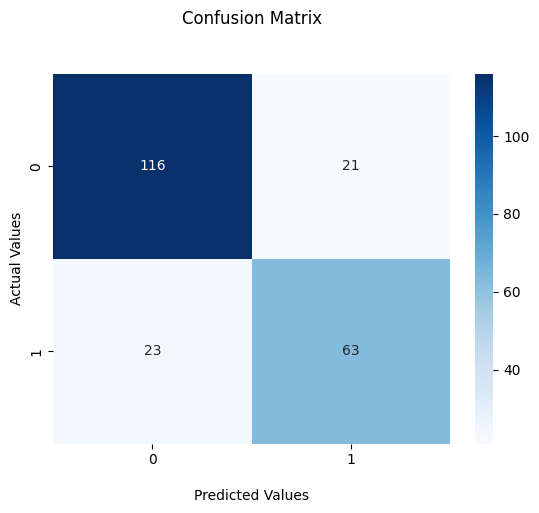

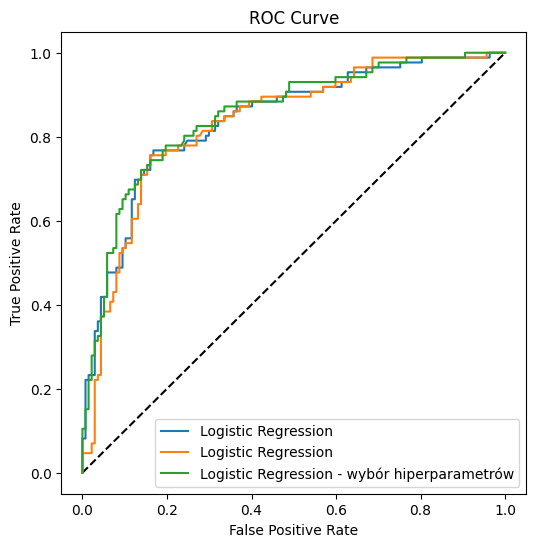

,Model,F1_score,AUC
0,Logistic Regression,0.729412,0.840477
1,Logistic Regression,0.741176,0.833517
2,Logistic Regression - wybór hiperparametrów,0.741176,0.852020


In [54]:
calculate_metrics(model_v3, 'Logistic Regression - wybór hiperparametrów', X_test, y_test)

Wyniki co prawda nie są jakoś znacząco lepsze, jednak to podejście jest najbardziej pożądane w uczeniu maszynowym – stworzony Pipeline do przygotowania danych i modelowania, dla którego następnie dobiera się hiperparametry, w oparciu o zbiory walidacyjne.